In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib as mpl

dataset = pd.read_csv("Airplane_Crashes_Since_1908.csv", encoding= 'unicode_escape')
dataset.head(1)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,2/25/1956,17:18,village of kolgot,PIA,NaN,Demonstration,PESSENGER,NaN,1.0,3.0,3.0,0.0,Unkown


In [ ]:
dataset.tail(1)


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"During its first approach, the aircraft experi..."


In [ ]:
dataset.count()


Date            19
Time            10
Location        19
Operator        19
Flight #        18
Route            2
Type            19
Registration     0
cn/In            1
Aboard          19
Fatalities      19
Ground          19
Summary         20
dtype: int64

In [ ]:
dataset['Date'] = pd.to_datetime(dataset['Date'])
dataset['Year'] = dataset['Date'].dt.year
dataset['Survived'] = dataset['Aboard'] - dataset['Fatalities']
dataset.head(1)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Year,Survived
0,1956-02-25,17:18,village of kolgot,PIA,NaN,Demonstration,PESSENGER,NaN,1.0,3.0,3.0,0.0,Unkown,1956.0,0.0


Text(0, 0.5, 'Number of Crash')

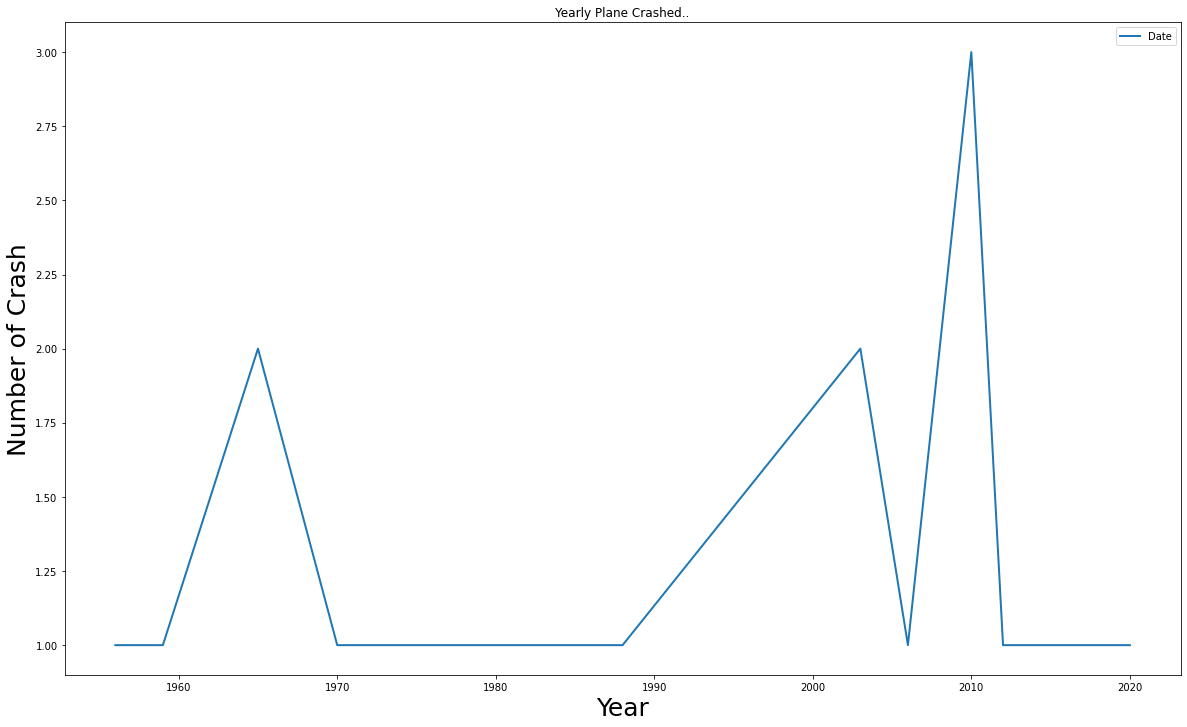

In [ ]:
yearlyCrashed = dataset.loc[:, ["Year","Date"]].groupby(['Year']).count()
plot1 = yearlyCrashed.plot(lw=2, title='Yearly Plane Crashed..', figsize=(20,12))
plot1.set_xlabel("Year", fontsize=25)
plot1.set_ylabel("Number of Crash", fontsize=25)

Text(0, 0.5, 'Numbers of People Aboard')

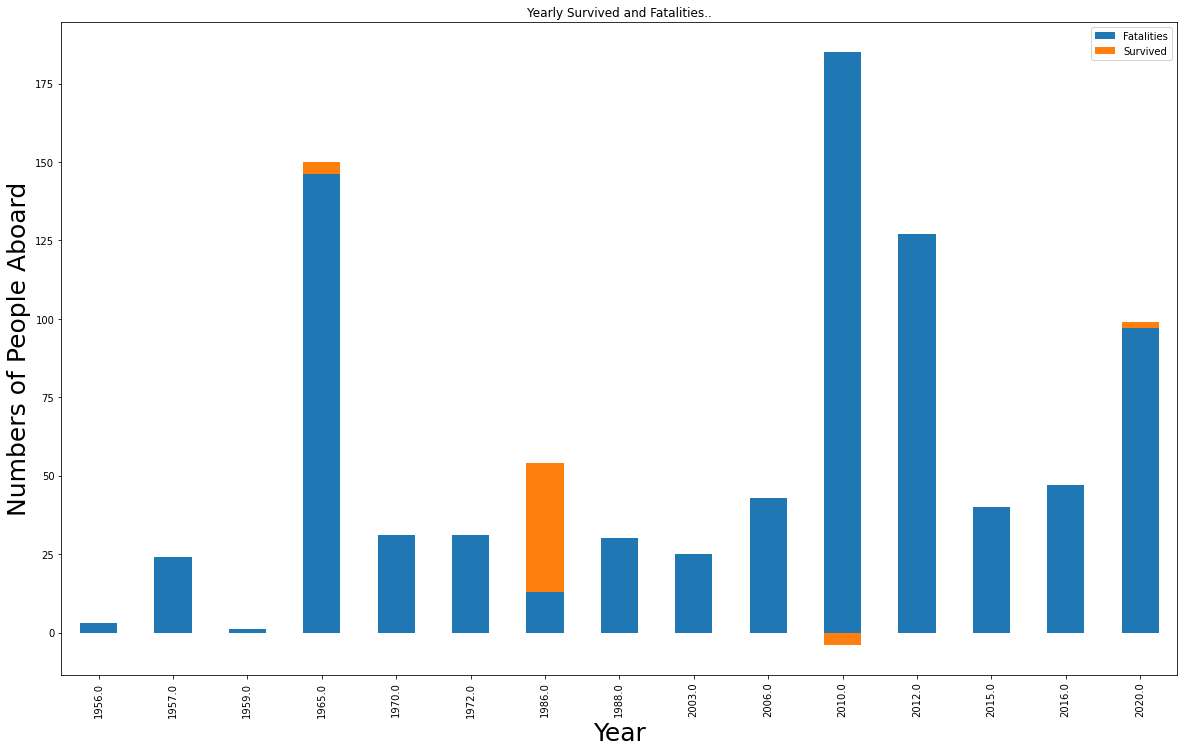

In [ ]:
yearlyStats = dataset.loc[:, ["Year","Fatalities", "Survived"]].groupby(['Year']).sum()
plot2 = yearlyStats.plot.bar(stacked=True, title='Yearly Survived and Fatalities..', figsize=(20,12))
plot2.set_xlabel("Year", fontsize=25)
plot2.set_ylabel("Numbers of People Aboard", fontsize=25)

In [ ]:
import pandas as pd
dataset = pd.read_csv("Airplane_Crashes_Since_1908.csv", encoding= 'unicode_escape')

crashedByOperator = dataset.loc[:, ["Operator","Date"]].groupby(['Operator']).count()
crashedByOperator = crashedByOperator.sort_values(by="Date", ascending=False).head(10)
plot3 = crashedByOperator.plot.bar( fontsize=16, colormap='Accent', figsize=(20,10), title="Top 10 Operator By Plane Crash")
plot3.set_xlabel("Operator", fontsize=20,)
plot3.set_ylabel("Number of Crash", fontsize=20,)

FileNotFoundError: ignored

array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fcf6a59aa90>],
      dtype=object)

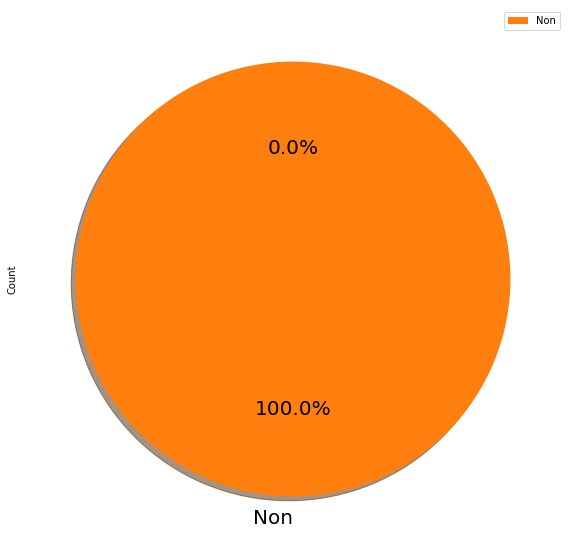

In [ ]:
military = dataset['Operator'].dropna().str.lower().str.replace(" ", "").str.split("-")
military = military[military.str.get(0)=='military']
aType = ['Military', 'Non']
values = {}
values['Count'] = [len(military), len(dataset)-len(military)]
operator = pd.DataFrame(values, index=aType)
operator.plot.pie(subplots=True, autopct='%1.1f%%', shadow=True, startangle=90, fontsize=20, figsize=(10, 10))

Text(0, 0.5, 'Number of Crash')

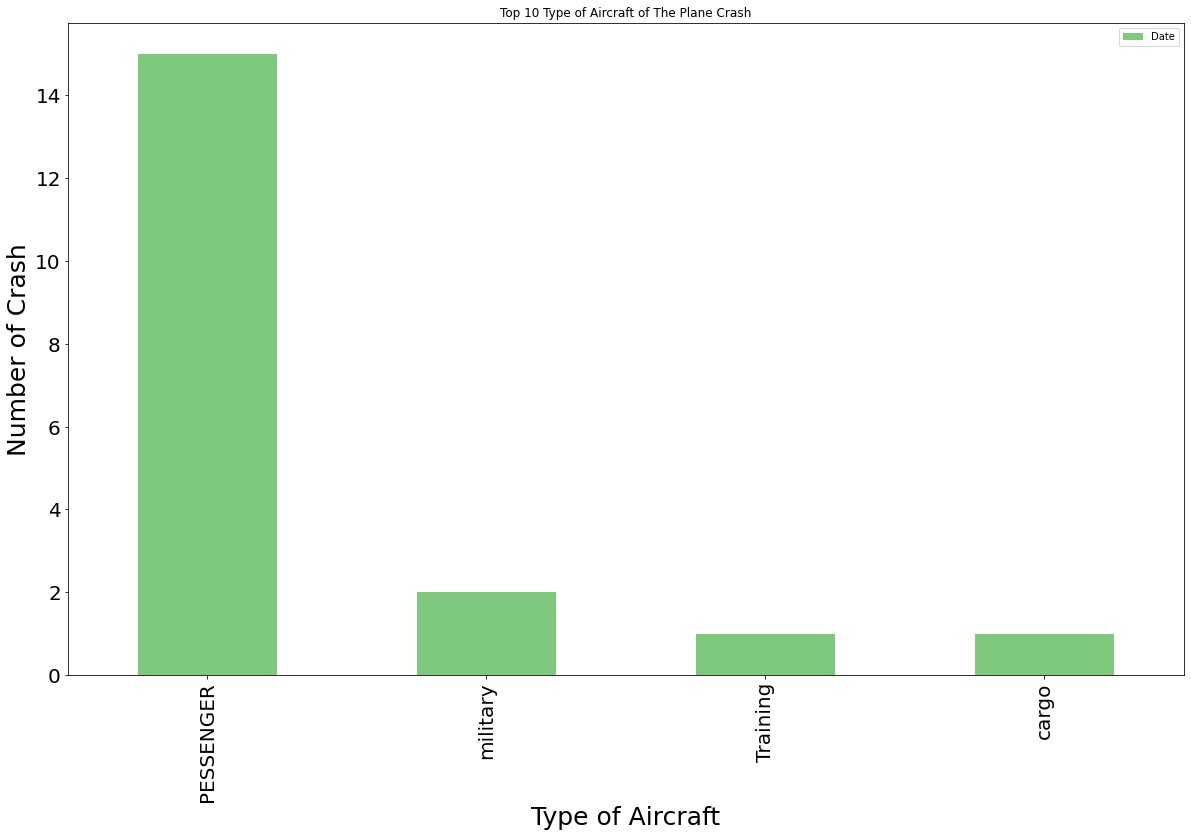

In [ ]:
crashedByType = dataset.loc[:, ["Type","Date"]].groupby(['Type']).count()
crashedByType = crashedByType.sort_values(by="Date", ascending=False).head(10)
plot4 = crashedByType.plot.bar(figsize=(20,12), colormap='Accent',
                               title="Top 10 Type of Aircraft of The Plane Crash", fontsize=20)
plot4.set_xlabel("Type of Aircraft", fontsize=25)
plot4.set_ylabel("Number of Crash", fontsize=25)

In [ ]:
import random
text = list(dataset["Summary"])
l = len(text)
with open("random-summary.txt", "w") as f:
    for x in range(200):
        n = random.randint(0,l-1)
        f.write(str(text[n]))
        f.write("\n")
import textblob
stringText = textblob.TextBlob(str(list(dataset["Summary"]))).lower()
words = stringText.word

wordCount = {}
ignore = ['a', 'an', 'the', "'the", 'and', 'to', 'of', 'in', 'into', 'is', 'was', 'on', 'at', 'from', 'with',
          'while', 'for', "'s", 'as', 'not', 'by', 'after', 'during']

for word in words:
    if word in ignore:
        continue
    if word in wordCount:
        wordCount[word] = wordCount[word] + 1
    else:
        wordCount[word] = 1


import operator
sorted_word = sorted(wordCount.items(), key=operator.itemgetter(1), reverse=True)[:500]
with open("sorted-word-count.txt", "w") as f:
    f.write(str(sorted_word))

reasons = ['weather', 'fire', 'shot down', 'stall/runway', 'pilot/crew error', 'systems failure']

expresion = ['((poor|bad).*(weather|visibility)|thunderstorm|fog)','(caught fire)|(caught on fire)',
           '(shot down) | (terrorist) | (terrorism)', '(stall)|(runway)', '(pilot|crew) (error|fatigue)',
            '(engine.*(fire|fail))|(structural fail)|(fuel leak)|(langing gear)|(turbulence)|(electrical)|(out of fuel)|(fuel.*exhaust)']


In [ ]:
dataset['Label'] = pd.Series(np.nan, index=dataset.index)
dataset.head(1)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Year,Survived,Label
0,1956-02-25,17:18,village of kolgot,PIA,NaN,Demonstration,PESSENGER,NaN,1.0,3.0,3.0,0.0,Unkown,1956.0,0.0,NaN


In [ ]:
trainData = []
import pandas as pd
import numpy as np
import re

dataset = pd.read_csv(r"Airplane_Crashes_Since_1908.csv", encoding= 'unicode_escape')

dataset['Label'] = pd.Series(np.nan, index=dataset.index)
dataset.head(1)
reasons = ['weather', 'fire', 'shot down', 'stall/runway', 'pilot/crew error', 'systems failure']

expresion = ['((poor|bad).*(weather|visibility)|thunderstorm|fog)','(caught fire)|(caught on fire)',
           '(shot down) | (terrorist) | (terrorism)', '(stall)|(runway)', '(pilot|crew) (error|fatigue)',
            '(engine.*(fire|fail))|(structural fail)|(fuel leak)|(langing gear)|(turbulence)|(electrical)|(out of fuel)|(fuel.*exhaust)']

for x in range(len(dataset)):
    if dataset.loc[x,"Summary"] is np.nan:
        dataset.loc[x,"Label"] = "unknown"
    else:
        for y in range(len(expresion)):
            if re.search(expresion[y], dataset.loc[x,"Summary"].lower()):
                dataset.loc[x,"Label"] = reasons[y]
                temp = dataset.loc[x,"Summary"].lower(), dataset.loc[x,"Label"]
                trainData.append(temp)
                break

In [ ]:
len(trainData)


0

In [ ]:

from textblob.classifiers import NaiveBayesClassifier
cl = NaiveBayesClassifier(trainData)


**********************************************************************
  Resource punkt not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt')
  
  Searched in:
    - '/root/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - '/usr/nltk_data'
    - '/usr/lib/nltk_data'
    - ''
**********************************************************************



MissingCorpusError: ignored

In [ ]:
reasons.append("unknown")
for x in range(30,len(dataset)):
    if dataset.loc[x,"Label"] in reasons:
       continue
    else:
        dataset.loc[x,"Label"] = cl.classify(dataset.loc[x,"Summary"])

# dataset = pd.read_csv("Airplane_Crashes_Updated.csv")
# dataset.to_csv("Airplane_Crashes_Updated.csv")

In [ ]:
label = dataset.loc[:,["Fatalities","Label"]].groupby("Label").count()
label.plot.pie(subplots=True, autopct='%1.1f%%', shadow=False, startangle=90, fontsize=10, figsize=(15, 15))

In [ ]:
deathByLabel = dataset.loc[:,["Fatalities","Label"]].groupby("Label").sum()
deathByLabel.plot.pie(subplots=True, autopct='%1.1f%%', shadow=False, startangle=90, fontsize=10, figsize=(15, 15))

IndexError: ignored

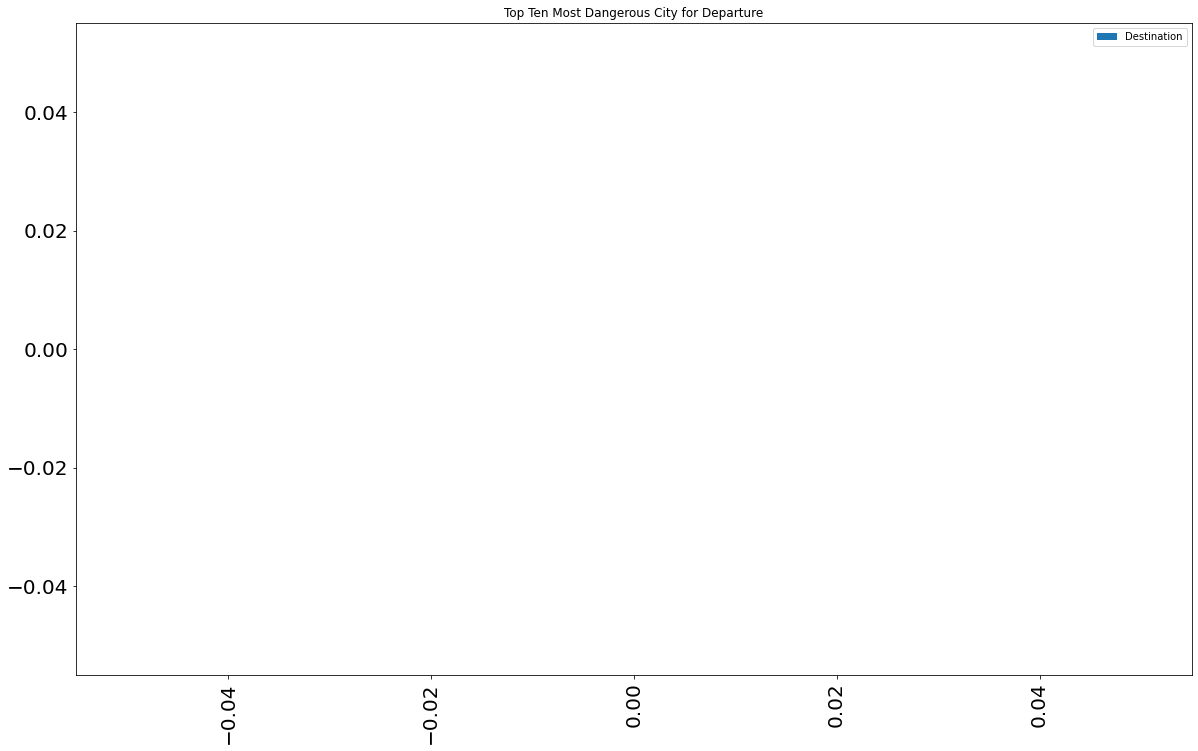

In [ ]:
routes=dataset['Route']
routes=routes.dropna().str.lower().str.replace(" ", "").str.split("-")
routes=routes[routes.str.len()==2]
dept2Dest=pd.DataFrame({'Departure': routes.str.get(0), 'Destination': routes.str.get(1)})
departure = dept2Dest.groupby(['Departure']).count().sort_values(by="Destination", ascending=False).head(10)
plot8 = departure.plot.bar(figsize=(20,12), title="Top Ten Most Dangerous City for Departure", fontsize=20)
plot8.set_xlabel("City", fontsize=25)
plot8.set_ylabel("Number of Crash", fontsize=25)

In [ ]:
destination = dept2Dest.groupby(['Destination']).count().sort_values(by="Departure", ascending=False).head(10)
plot8 = destination.plot.bar(figsize=(20,12), title="Top Ten Most Dangerous City for Destination", fontsize=20)
plot8.set_xlabel("City", fontsize=25)
plot8.set_ylabel("Number of Crash", fontsize=25)

NameError: ignored